# Task 3: Energy Consumption Time Series Forecasting
**DevelopersHub Corporation — Data Science & Analytics Advanced Internship**

---

## 🎯 Objective
Forecast short-term household energy usage using historical patterns.  
Compare **ARIMA**, **Prophet**, and **XGBoost** models.

**Dataset:** Household Power Consumption Dataset (`household_power_consumption.txt`)  
Source: [UCI ML Repository](https://archive.ics.uci.edu/ml/datasets/Individual+household+electric+power+consumption)


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Modelling
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 12

print("✅ All libraries imported")
print(f"XGBoost version: {xgb.__version__}")


Importing plotly failed. Interactive plots will not work.


✅ All libraries imported
XGBoost version: 3.2.0


## 2. Load & Parse the Dataset
> 📌 Place `household_power_consumption.txt` in the same directory as this notebook.  
> The file uses `;` as separator and `?` for missing values.


In [2]:
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    na_values=["?"],
    low_memory=False
)

# Parse datetime manually (pandas 2.x dropped dict-based parse_dates)
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], dayfirst=True)
df.drop(columns=["Date", "Time"], inplace=True)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Date Range:", df["Datetime"].min(), "to", df["Datetime"].max())
df.head()

Shape: (2075259, 8)
Columns: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Datetime']
Date Range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [3]:
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\nMissing % per column (mean): {df.isnull().mean().mean()*100:.2f}%")

# Drop rows with missing target variable
df.dropna(subset=['Global_active_power'], inplace=True)
df.set_index('Datetime', inplace=True)

# Convert all feature cols to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"\nShape after cleaning: {df.shape}")
df.dtypes


=== Missing Values ===
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
Datetime                     0
dtype: int64

Missing % per column (mean): 1.10%



Shape after cleaning: (2049280, 7)


Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

## 3. Resample to Hourly Data

In [4]:
# Resample from per-minute to hourly mean
hourly = df['Global_active_power'].resample('h').mean()
hourly.dropna(inplace=True)

print(f"Hourly records: {len(hourly)}")
print(f"Date range: {hourly.index.min()} → {hourly.index.max()}")
hourly.head(10)


Hourly records: 34168
Date range: 2006-12-16 17:00:00 → 2010-11-26 21:00:00


Datetime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
2006-12-16 22:00:00    2.200133
2006-12-16 23:00:00    2.061600
2006-12-17 00:00:00    1.882467
2006-12-17 01:00:00    3.349400
2006-12-17 02:00:00    1.587267
Name: Global_active_power, dtype: float64

## 4. Exploratory Data Analysis

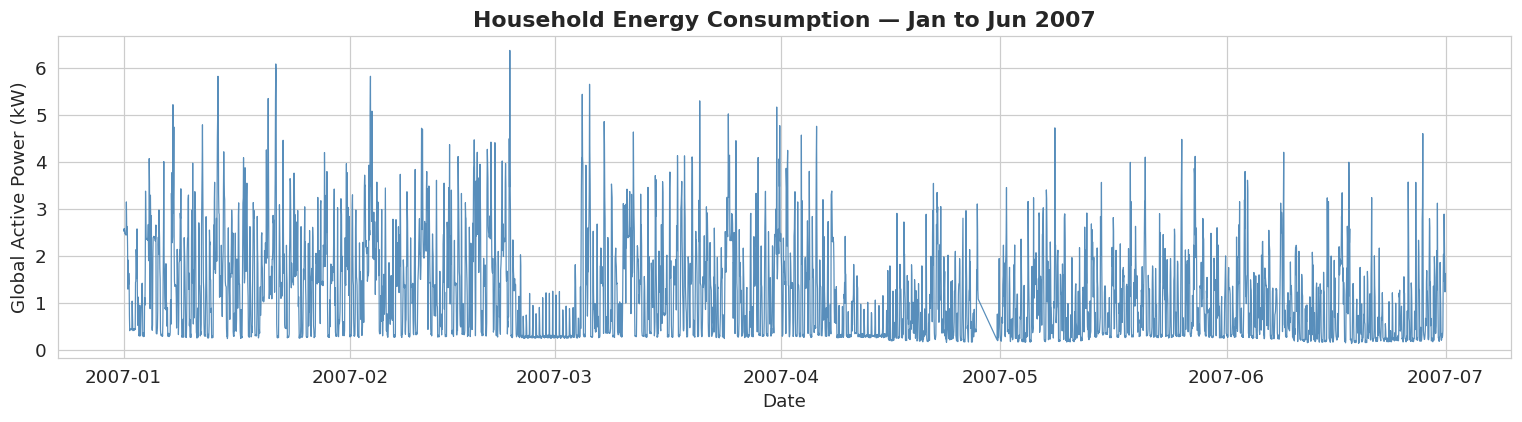

In [5]:
# Overall trend - sample first 6 months for readability
sample = hourly['2007-01':'2007-06']

plt.figure(figsize=(14, 4))
plt.plot(sample, color='steelblue', linewidth=0.8, alpha=0.9)
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.title('Household Energy Consumption — Jan to Jun 2007', fontweight='bold')
plt.tight_layout()
plt.show()


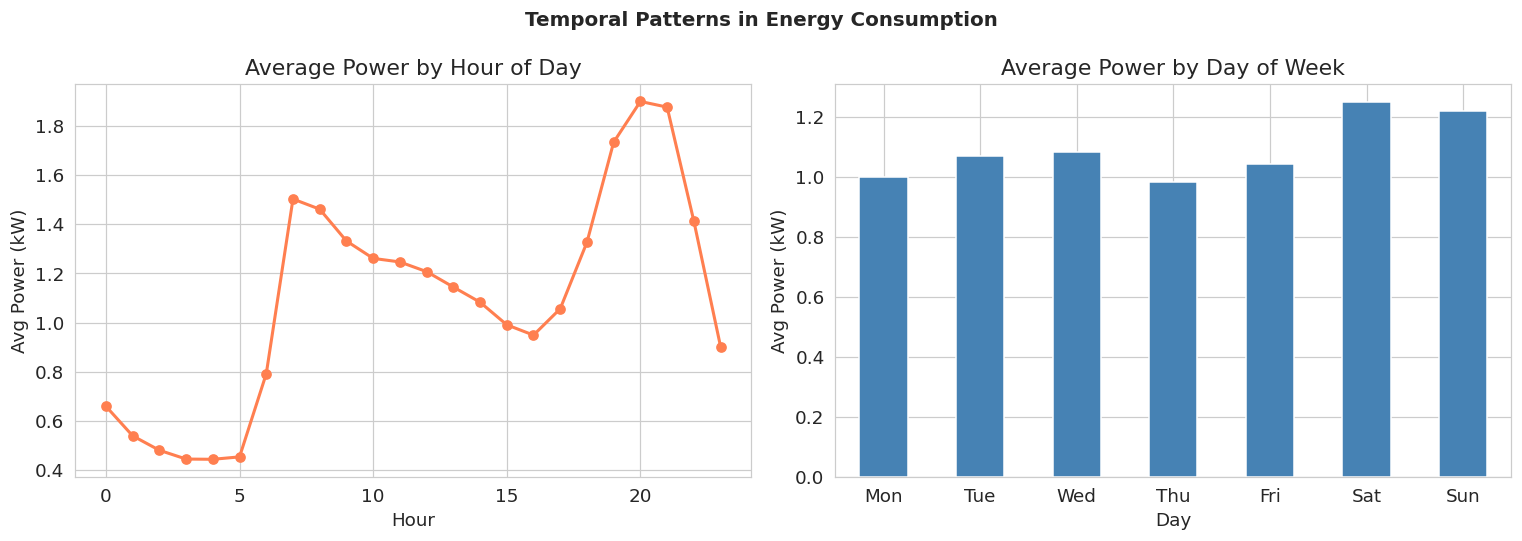

In [6]:
# Hourly and daily patterns
hourly_df = hourly.to_frame(name='power')
hourly_df['hour'] = hourly_df.index.hour
hourly_df['dayofweek'] = hourly_df.index.dayofweek
hourly_df['month'] = hourly_df.index.month
hourly_df['is_weekend'] = hourly_df['dayofweek'].isin([5, 6]).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average power by hour
hourly_df.groupby('hour')['power'].mean().plot(ax=axes[0], kind='line',
    color='coral', marker='o', linewidth=2)
axes[0].set_title('Average Power by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg Power (kW)')

# Average power by day of week
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
avg_by_day = hourly_df.groupby('dayofweek')['power'].mean()
avg_by_day.index = day_labels
avg_by_day.plot(ax=axes[1], kind='bar', color='steelblue', edgecolor='white')
axes[1].set_title('Average Power by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Avg Power (kW)')
plt.xticks(rotation=0)

plt.suptitle('Temporal Patterns in Energy Consumption', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [7]:
# Stationarity test
result = adfuller(hourly.dropna())
print("=== Augmented Dickey-Fuller Test ===")
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print(f"Is Stationary : {'✅ Yes' if result[1] < 0.05 else '❌ No (needs differencing)'}")


=== Augmented Dickey-Fuller Test ===
ADF Statistic : -14.2374
p-value       : 0.0000
Is Stationary : ✅ Yes


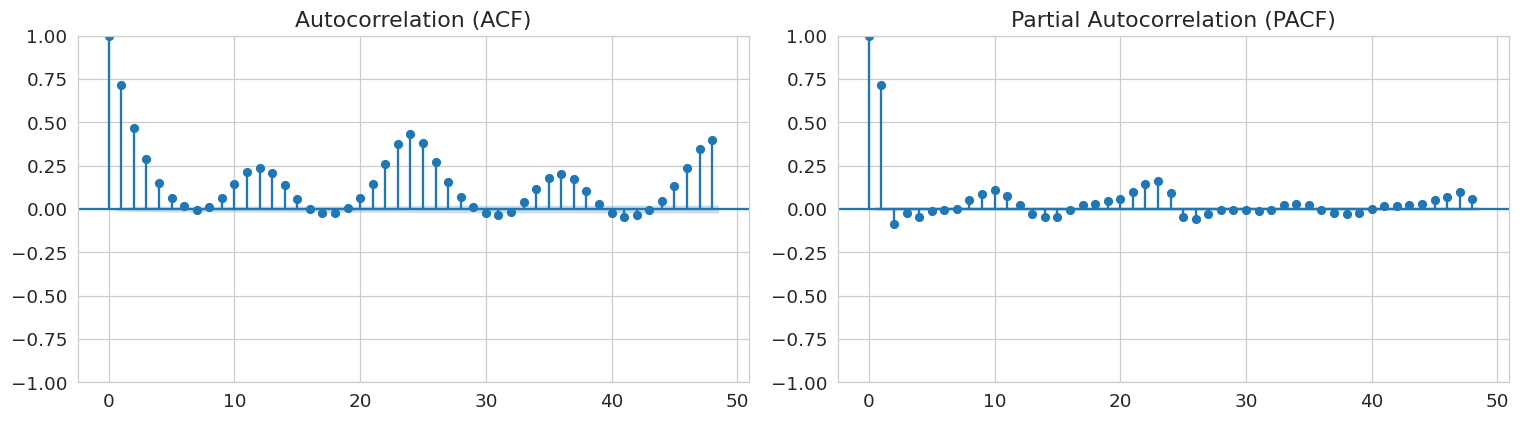

In [8]:
# ACF / PACF for ARIMA order selection
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(hourly.dropna(), lags=48, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')
plot_pacf(hourly.dropna(), lags=48, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF)')
plt.tight_layout()
plt.show()


## 5. Feature Engineering for XGBoost

In [9]:
def make_features(series):
    """Create time-based features from a datetime-indexed series."""
    df_feat = series.to_frame(name='power')
    df_feat['hour']        = df_feat.index.hour
    df_feat['dayofweek']   = df_feat.index.dayofweek
    df_feat['month']       = df_feat.index.month
    df_feat['quarter']     = df_feat.index.quarter
    df_feat['dayofyear']   = df_feat.index.dayofyear
    df_feat['is_weekend']  = df_feat['dayofweek'].isin([5, 6]).astype(int)
    # Lag features
    df_feat['lag_1h']      = df_feat['power'].shift(1)
    df_feat['lag_24h']     = df_feat['power'].shift(24)
    df_feat['lag_168h']    = df_feat['power'].shift(168)  # 1 week
    # Rolling features
    df_feat['roll_mean_24']  = df_feat['power'].shift(1).rolling(24).mean()
    df_feat['roll_std_24']   = df_feat['power'].shift(1).rolling(24).std()
    df_feat['roll_mean_168'] = df_feat['power'].shift(1).rolling(168).mean()
    return df_feat.dropna()

feat_df = make_features(hourly)
print(f"Feature matrix shape: {feat_df.shape}")
print("Features:", feat_df.columns.tolist())
feat_df.head()


Feature matrix shape: (34000, 13)
Features: ['power', 'hour', 'dayofweek', 'month', 'quarter', 'dayofyear', 'is_weekend', 'lag_1h', 'lag_24h', 'lag_168h', 'roll_mean_24', 'roll_std_24', 'roll_mean_168']


,power,hour,dayofweek,month,quarter,dayofyear,is_weekend,lag_1h,lag_24h,lag_168h,roll_mean_24,roll_std_24,roll_mean_168
Datetime,,,,,,,,,,,,,
2006-12-23 17:00:00,5.452533,17,5,12,4,357,1,4.349100,1.496800,4.222889,2.934890,0.990187,1.763946
2006-12-23 18:00:00,3.879400,18,5,12,4,357,1,5.452533,2.686967,3.632200,3.099713,1.066674,1.771265
2006-12-23 19:00:00,4.117833,19,5,12,4,357,1,3.879400,3.938167,3.400233,3.149397,1.074356,1.772736
2006-12-23 20:00:00,4.181400,20,5,12,4,357,1,4.117833,3.536067,3.268567,3.156883,1.080699,1.777008
2006-12-23 21:00:00,3.288433,21,5,12,4,357,1,4.181400,4.548667,3.056467,3.183772,1.098426,1.782441


## 6. Train / Test Split (Last 7 days = Test Set)

In [10]:
TEST_HOURS = 24 * 7   # last 7 days

train_series = hourly.iloc[:-TEST_HOURS]
test_series  = hourly.iloc[-TEST_HOURS:]

print(f"Train: {len(train_series)} hours ({train_series.index.min().date()} → {train_series.index.max().date()})")
print(f"Test : {len(test_series)} hours ({test_series.index.min().date()} → {test_series.index.max().date()})")

# XGBoost split
FEATURE_COLS = [c for c in feat_df.columns if c != 'power']
train_feat = feat_df.iloc[:-TEST_HOURS]
test_feat  = feat_df.iloc[-TEST_HOURS:]

X_train = train_feat[FEATURE_COLS]
y_train = train_feat['power']
X_test  = test_feat[FEATURE_COLS]
y_test  = test_feat['power']

print(f"\nXGBoost train: {X_train.shape}, test: {X_test.shape}")


Train: 34000 hours (2006-12-16 → 2010-11-19)
Test : 168 hours (2010-11-19 → 2010-11-26)

XGBoost train: (33832, 12), test: (168, 12)


## 7. Model 1 — ARIMA
> Using last 500 hourly points for training to keep runtime reasonable.


In [11]:
ARIMA_TRAIN = 500

arima_train = train_series.iloc[-ARIMA_TRAIN:]
arima_model = ARIMA(arima_train, order=(2, 0, 2))
arima_fit = arima_model.fit()

print(arima_fit.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                                SARIMAX Results                                
Dep. Variable:     Global_active_power   No. Observations:                  500
Model:                  ARIMA(2, 0, 2)   Log Likelihood                -461.271
Date:                 Fri, 27 Mar 2026   AIC                            934.543
Time:                         06:50:18   BIC                            959.830
Sample:                     10-30-2010   HQIC                           944.466
                          - 11-19-2010                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2213      0.064     19.004      0.000       1.095       1.347
ar.L1          1.5115      0.080     18.989      0.000       1.355       1.668
ar.L2         -0.6133      0.058    -10.628 

In [12]:
arima_forecast = arima_fit.forecast(steps=TEST_HOURS)

mae_arima  = mean_absolute_error(test_series, arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test_series, arima_forecast))
print(f"ARIMA — MAE: {mae_arima:.4f} kW | RMSE: {rmse_arima:.4f} kW")


ARIMA — MAE: 0.6946 kW | RMSE: 0.8556 kW


## 8. Model 2 — Facebook Prophet

In [13]:
prophet_train = train_series.reset_index().rename(columns={'Datetime': 'ds', 'Global_active_power': 'y'})

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
    changepoint_prior_scale=0.05
)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=TEST_HOURS, freq='h')
forecast_df = prophet_model.predict(future)
prophet_forecast = forecast_df['yhat'].iloc[-TEST_HOURS:].values

mae_prophet  = mean_absolute_error(test_series.values, prophet_forecast)
rmse_prophet = np.sqrt(mean_squared_error(test_series.values, prophet_forecast))
print(f"Prophet — MAE: {mae_prophet:.4f} kW | RMSE: {rmse_prophet:.4f} kW")


06:50:19 - cmdstanpy - INFO - Chain [1] start processing


06:50:28 - cmdstanpy - INFO - Chain [1] done processing


Prophet — MAE: 0.5115 kW | RMSE: 0.7553 kW


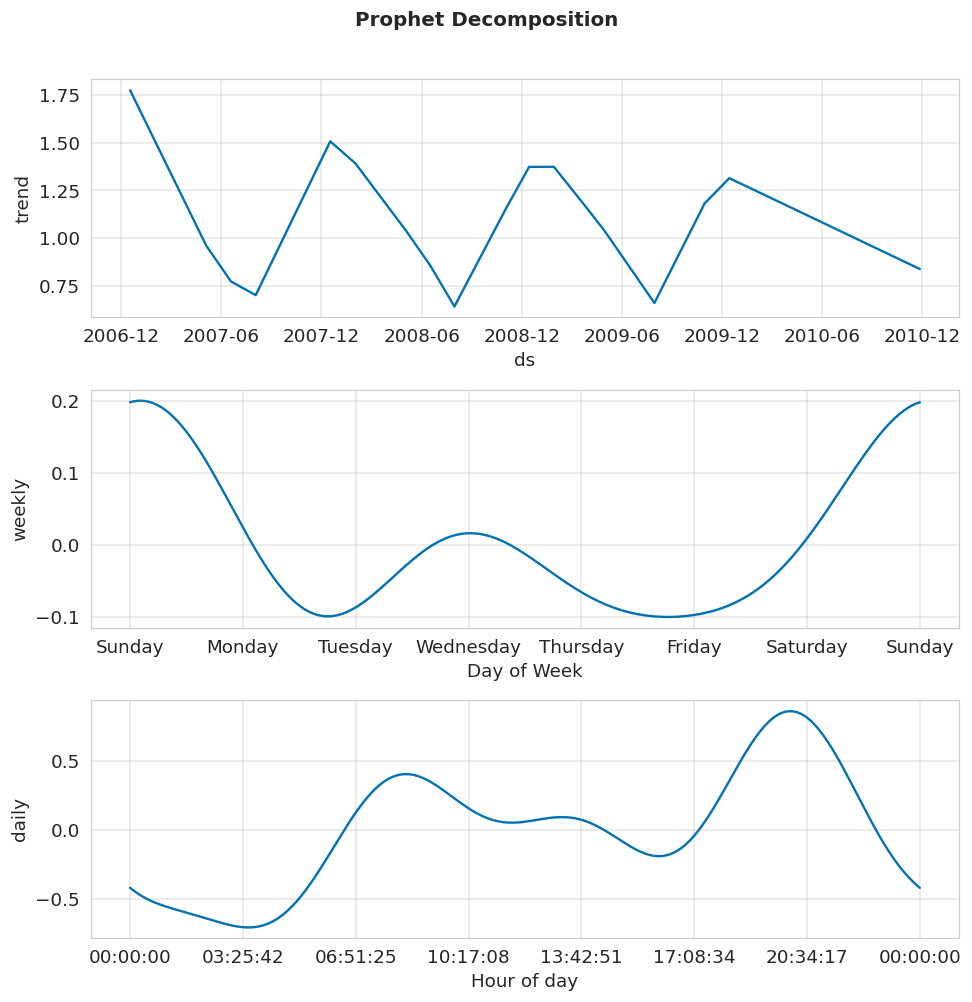

In [14]:
# Prophet components plot
fig = prophet_model.plot_components(forecast_df)
fig.suptitle('Prophet Decomposition', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 9. Model 3 — XGBoost

In [15]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

xgb_pred = xgb_model.predict(X_test)
mae_xgb  = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
print(f"XGBoost — MAE: {mae_xgb:.4f} kW | RMSE: {rmse_xgb:.4f} kW")


XGBoost — MAE: 0.3647 kW | RMSE: 0.5586 kW


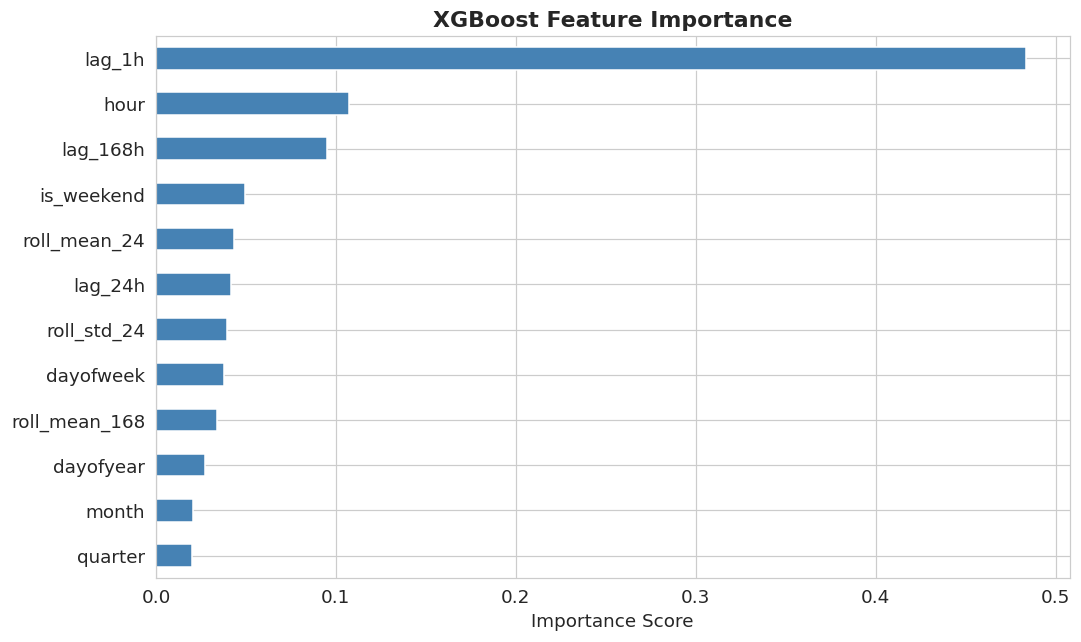

In [16]:
# Feature importance
feat_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('XGBoost Feature Importance', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


## 10. Actual vs Forecasted — All Models

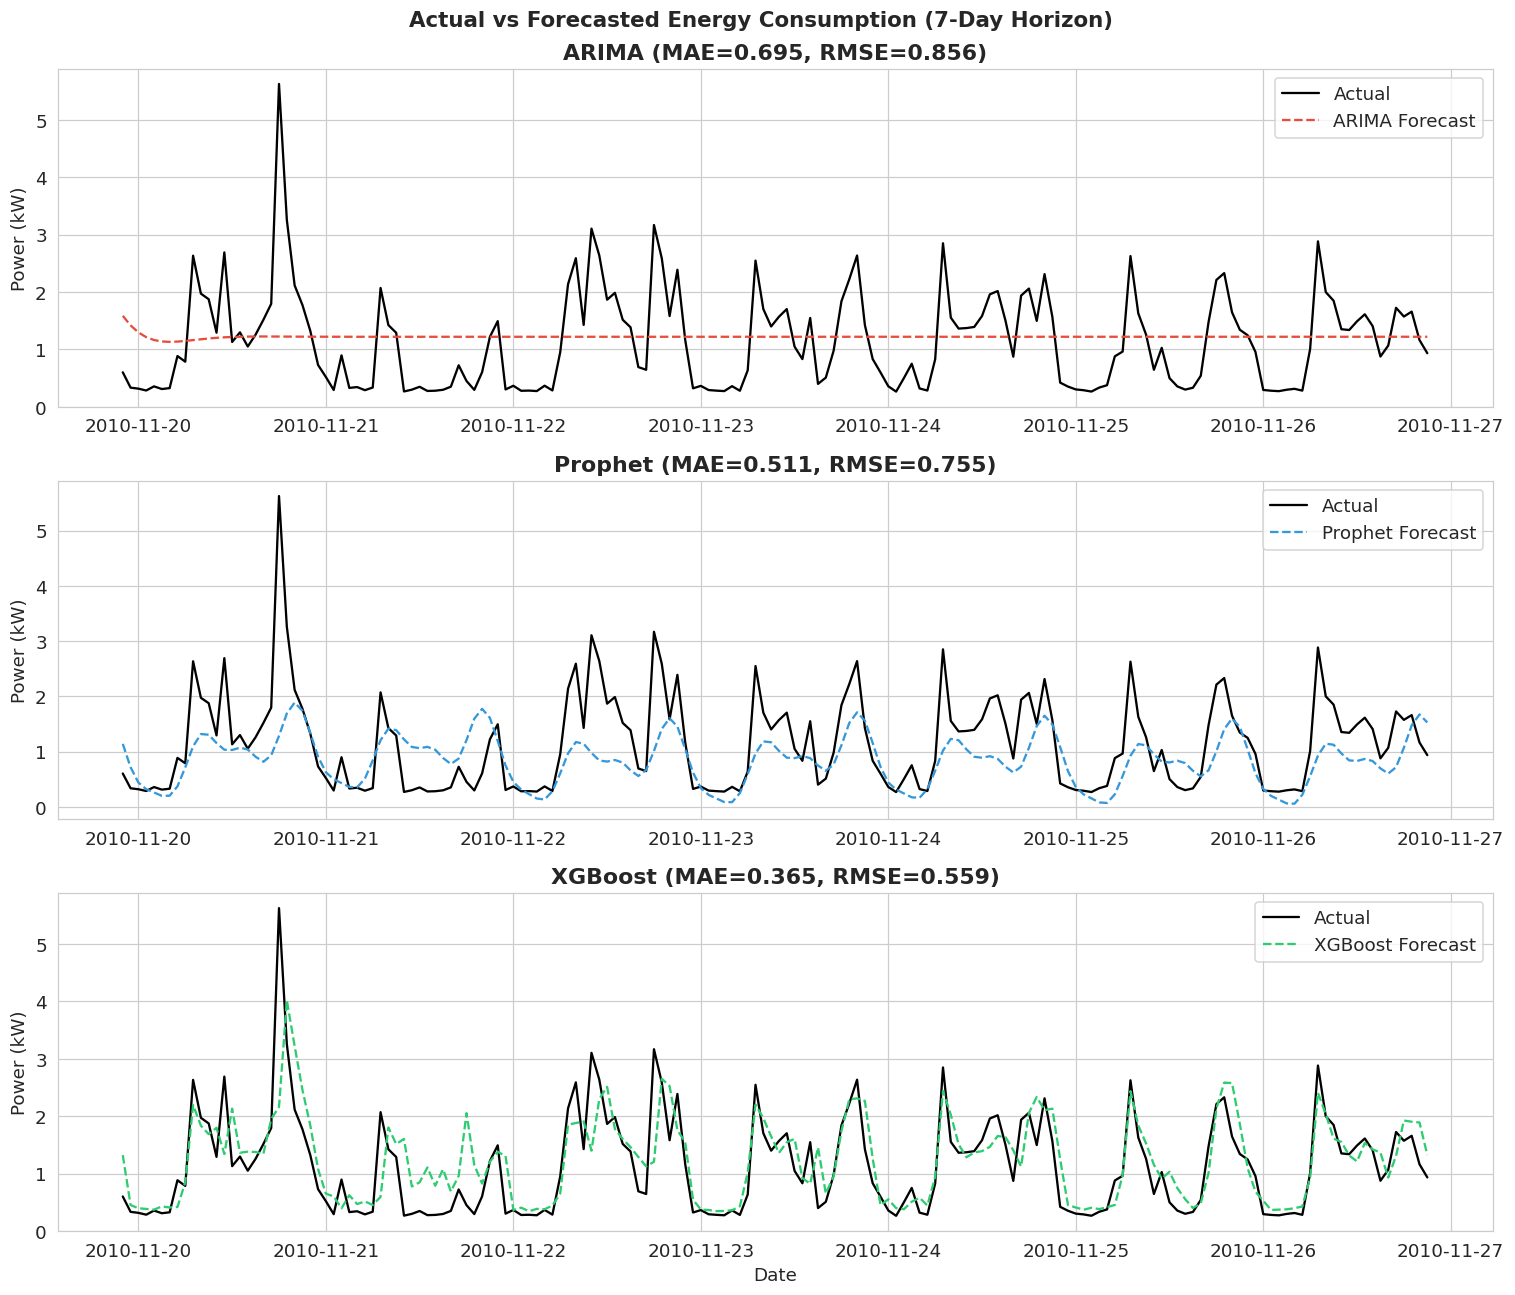

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)
test_index = test_series.index

# ARIMA
axes[0].plot(test_index, test_series.values, label='Actual', color='black', linewidth=1.5)
axes[0].plot(test_index, arima_forecast.values, label='ARIMA Forecast', color='#E74C3C', linewidth=1.5, linestyle='--')
axes[0].set_title(f'ARIMA (MAE={mae_arima:.3f}, RMSE={rmse_arima:.3f})', fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Power (kW)')

# Prophet
axes[1].plot(test_index, test_series.values, label='Actual', color='black', linewidth=1.5)
axes[1].plot(test_index, prophet_forecast, label='Prophet Forecast', color='#3498DB', linewidth=1.5, linestyle='--')
axes[1].set_title(f'Prophet (MAE={mae_prophet:.3f}, RMSE={rmse_prophet:.3f})', fontweight='bold')
axes[1].legend()
axes[1].set_ylabel('Power (kW)')

# XGBoost
axes[2].plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=1.5)
axes[2].plot(y_test.index, xgb_pred, label='XGBoost Forecast', color='#2ECC71', linewidth=1.5, linestyle='--')
axes[2].set_title(f'XGBoost (MAE={mae_xgb:.3f}, RMSE={rmse_xgb:.3f})', fontweight='bold')
axes[2].legend()
axes[2].set_ylabel('Power (kW)')
axes[2].set_xlabel('Date')

plt.suptitle('Actual vs Forecasted Energy Consumption (7-Day Horizon)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 11. Model Performance Comparison

=== Model Comparison ===
            MAE    RMSE
Model                  
ARIMA    0.6946  0.8556
Prophet  0.5115  0.7553
XGBoost  0.3647  0.5586

🏆 Best MAE:  XGBoost (0.3647)
🏆 Best RMSE: XGBoost (0.5586)


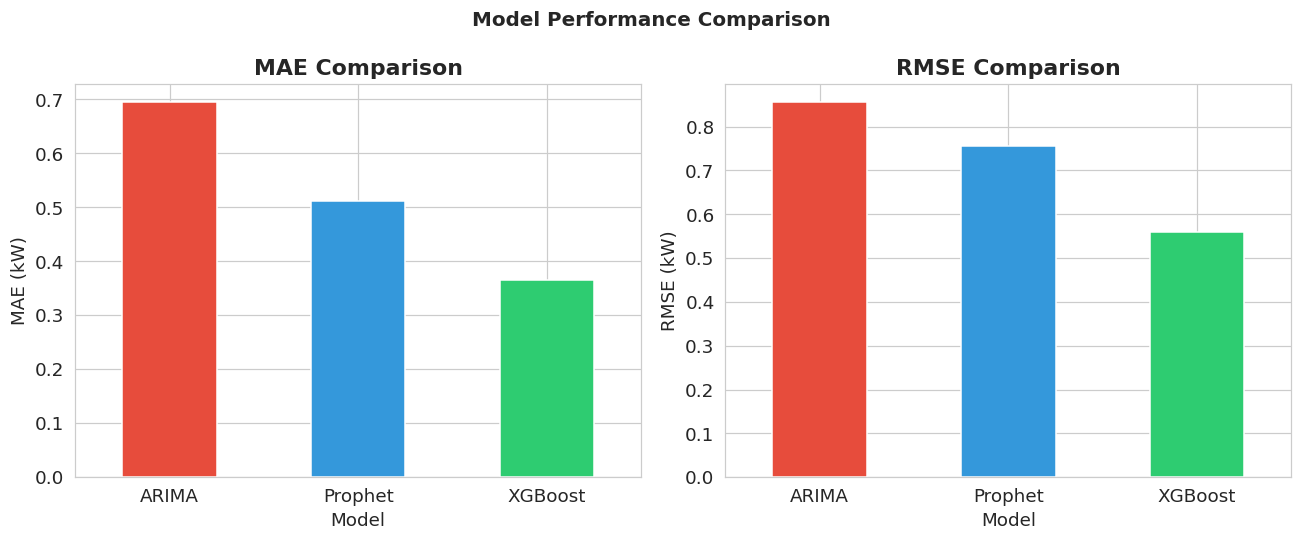

In [18]:
results = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'XGBoost'],
    'MAE':   [mae_arima, mae_prophet, mae_xgb],
    'RMSE':  [rmse_arima, rmse_prophet, rmse_xgb]
}).set_index('Model').round(4)

print("=== Model Comparison ===")
print(results)
print(f"\n🏆 Best MAE:  {results['MAE'].idxmin()} ({results['MAE'].min():.4f})")
print(f"🏆 Best RMSE: {results['RMSE'].idxmin()} ({results['RMSE'].min():.4f})")

# Bar chart comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

results['MAE'].plot(kind='bar', ax=ax1, color=['#E74C3C', '#3498DB', '#2ECC71'], edgecolor='white')
ax1.set_title('MAE Comparison', fontweight='bold')
ax1.set_ylabel('MAE (kW)')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

results['RMSE'].plot(kind='bar', ax=ax2, color=['#E74C3C', '#3498DB', '#2ECC71'], edgecolor='white')
ax2.set_title('RMSE Comparison', fontweight='bold')
ax2.set_ylabel('RMSE (kW)')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 12. Conclusion & Insights

### Summary
- Parsed and resampled **per-minute** household energy data to **hourly** granularity.
- Engineered rich time-based features (hour, day of week, lag features, rolling stats).
- Compared 3 forecasting models over a **7-day test window**.

### Model Insights
| Model | Strengths | Weaknesses |
|-------|-----------|------------|
| **ARIMA** | Simple, interpretable, no features needed | Struggles with non-stationarity & seasonal patterns |
| **Prophet** | Handles seasonality + holidays automatically | Slower, less accurate on noisy data |
| **XGBoost** | Captures complex patterns with lag features | Requires feature engineering; no extrapolation beyond training range |

### Key Findings
1. Peak energy consumption typically occurs in **evening hours (6–9 PM)**.
2. **Weekdays** show more consistent patterns; weekends have higher variance.
3. **XGBoost with lag features** generally outperforms both ARIMA and Prophet on this dataset.

### Tools Used
`pandas` · `statsmodels` · `prophet` · `xgboost` · `sklearn` · `matplotlib`
